# 09 — Vergelijking van Andrew's Mushroom-modellen

**Bijdragen:** Andrew Noeyens leverde de bronnotebook/modeldefinities en modelbestanden;
Jorre Van Dyck vroeg de vergelijking; Codex implementeerde en voerde de reproductie,
kruisvalidatie, foutanalyse en rapportage uit. De inhoudelijke teamreview staat nog open.

Dit notebook verzamelt en onderzoekt de gecontroleerde resultaten van dezelfde 5.000-rijenversie.
Het is **geen definitieve ranglijst voor alle UCI/AWS-modellen**. Broncommit: `17c4a61`.
Het volledige rapport staat in [09_andrew_vergelijkingsrapport.md](09_andrew_vergelijkingsrapport.md).

Elke codecel wordt vooraf uitgelegd. Opgeslagen outputs behouden het bewijs voor de inlevering.


## 1. Reproduceerbare omgeving en resultaatbestanden

Voer de twee scripts uit volgens het rapport met `comparison-requirements.txt` in een aparte
omgeving. Hieronder laden we standaard de opgeslagen resultaten. Zet `RUN_TRAINING=True`
om alle pipelines opnieuw te trainen op de vijf identieke folds en de 4.100 trainingsrecords.
Het script legt de CV-keuze vast vóór het berekenen van testmetrics. Preprocessing wordt
per fold gefit; oorspronkelijke bestanden worden behouden.

**Let op:** opnieuw uitvoeren met True overschrijft de vergelijkingsoutputs. Bouw daarna
ook het Markdownrapport opnieuw met `build_comparison_report.py --execute`.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'SolutionAndrew/MushroomDataset/mushroom_project_dataset.csv').exists())
FOLDER = ROOT / 'secondary_mushroom'
OUT = FOLDER / 'comparison_andrew'
sys.path.insert(0, str(FOLDER))
from compare_andrew_models import run, NAMES, clean_measurements, fingerprint

RUN_TRAINING = False
if RUN_TRAINING:
    run()
summary = json.loads((OUT / 'comparison_summary.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(OUT / 'model_comparison.csv').set_index('model')
folds = pd.read_csv(OUT / 'cv_folds.csv')
split = pd.read_csv(OUT / 'split_manifest.csv')
predictions = pd.read_csv(OUT / 'test_predictions.csv')
errors = pd.read_csv(OUT / 'selected_model_errors.csv')
display(pd.Series(summary['environment'], name='omgeving van de trainingsrun'))
print('Modelkeuze:', NAMES[summary['selected_model']])

python                             3.13.7
platform        Windows-11-10.0.26200-SP0
logical_cpus                           20
sklearn                             1.9.1
pandas                              3.0.2
numpy                               2.5.3
scipy                              1.18.1
joblib                              1.6.0
xgboost                             3.4.1
Name: omgeving van de trainingsrun, dtype: object

Modelkeuze: Random Forest 500


## 2. Datasetidentiteit, labels en split

We controleren de datahash en aantallen zodat cijfers niet stilzwijgend uit verschillende
dataversies worden samengevoegd. `source_row` verwijst naar de rij-index (vanaf nul) in de CSV.
`p` is de positieve klasse, `e` de negatieve. Andrew's split is gestratificeerd 82/18 met seed 42;
op de 4.100 trainingsrecords komen vijf gestratificeerde CV-folds. Elke trainingsrij is precies
één keer validatierij. Deze bestaande testset was al bekeken in de bronnotebook, en is dus
een ontwikkeltestset. Exacte overlapchecks sluiten verwante gesimuleerde records niet uit.


In [2]:
source = ROOT / 'SolutionAndrew/MushroomDataset/mushroom_project_dataset.csv'
data = pd.read_csv(source)
assert fingerprint(source)['sha256_lf'] == summary['dataset']['sha256_lf']
assert len(split) == 5000 and split.source_row.is_unique
assert (split.split == 'train').sum() == 4100
assert (split.split == 'test').sum() == 900
assert split.loc[split.split == 'train', 'cv_validation_fold'].notna().all()
assert split.loc[split.split == 'test', 'cv_validation_fold'].isna().all()
assert set(predictions.source_row) == set(split.loc[split.split == 'test', 'source_row'])
display(pd.crosstab(split.split, split['class']))
display(split[split.split == 'train'].cv_validation_fold.value_counts().sort_index())
print('Exacte duplicaten:', summary['dataset']['exact_duplicate_rows'])
print('Exacte feature-overlap train/test:', summary['dataset']['overlapping_exact_feature_rows_train_test'])
display(pd.Series(summary['dataset']['missing_percent_after_cleaning'], name='ontbrekend (%)'))

class,e,p
split,,
test,559,341
train,2548,1552


cv_validation_fold
1.0    820
2.0    820
3.0    820
4.0    820
5.0    820
Name: count, dtype: int64

Exacte duplicaten: 0
Exacte feature-overlap train/test: 0


cap-diameter         40.64
stem-height          21.24
stem-width            9.04
spore-print-color    94.80
gill-color           19.78
habitat              20.08
season               19.46
ring-type            11.54
cap-shape             8.12
stem-surface         67.18
jumbled_noise_0       8.12
jumbled_noise_1       8.12
Name: ontbrekend (%), dtype: float64

## 3. Kandidaten en opgeslagen modelbestanden


Bronmap: [SolutionAndrew/MushroomDataset](../SolutionAndrew/MushroomDataset/).
Andrew's huidige `mushroom.ipynb` bevat vier classifiers. Twee `.pkl`-bestanden bevatten
opgeslagen pipelines. Die bestanden zijn met **joblib** opgeslagen.

| Kandidaat | Instellingen die opnieuw zijn uitgevoerd | Reden voor vergelijking |
| --- | --- | --- |
| Meerderheidsreferentie | Altijd `e` voorspellen | Laat zien waarom accuracy alleen onvoldoende is |
| Random Forest 500 | 500 bomen; depth 20; min split 3; min leaf 1; max features sqrt; balanced class weights | Boomensemble kan categorische combinaties en niet-lineaire patronen modelleren |
| Gradient Boosting | 350 bomen; learning rate 0,08; depth 8; min split 4; min leaf 2; subsample 1 | Sequentiële bomen corrigeren eerdere fouten; relatief diepe bomen kunnen overfitten |
| XGBoost | 500 bomen; learning rate 0,05; depth 5; min child weight 2; subsample en colsample 0,8 | Andere boostingimplementatie met sampling en regularisatiemogelijkheden |
| Logistic Regression + poly | Numerieke polynomial features graad 2; scaling; C=1; balanced; max iter 3.000 | Vergelijking met een eenvoudiger beslisfunctie en beperkte numerieke interacties |
| Logistic Regression v1-config | Geen polynomial features; numerieke missing indicators en scaling; C=1; geen class weights; max iter 2.000 | Controle van de werkelijk opgeslagen LR-configuratie |

**De opgeslagen Logistic Regression is een ander model dan de huidige notebookvariant.**
We vergelijken daarom beide configuraties apart. De v1-configuratie wordt vanuit de
opgeslagen pipeline gekloond en opnieuw getraind; `clone` neemt geen aangeleerde parameters
mee. Hierdoor gebruikt ook deze kandidaat precies dezelfde nieuwe CV-folds en trainingsset.

De opgeslagen Gradient Boosting reproduceert de notebookconfiguratie. Voor beide opgeslagen
pipelines komen de labels én de waarschijnlijkheidsscores op deze 900 records exact overeen
met hun opnieuw getrainde tegenhanger. Hun oorspronkelijke trainingslidmaatschap is niet
apart bewezen; de hoofdvergelijking berust daarom op de gecontroleerde hertraining.

Het oudere bestand `models/random_forest.joblib` bevat **200 bomen**, gebruikt een eerdere
80/20-split en hoort bij de huidige API-configuratie. Het is niet het RF500-model uit de
nieuwste notebook. Voor RF500 en XGBoost staan in deze broncommit modeldefinities en outputs,
maar geen nieuwe afzonderlijk geëxporteerde modelbestanden. In de onderzochte notebook staat
geen vastgelegd GridSearch/RandomizedSearch-traject; gekozen hyperparameters zijn niet op
zichzelf bewijs van systematische tuning.



In [3]:
artifact_rows = []
for key, audit in summary['artifact_audit'].items():
    path = ROOT / audit['path']
    assert fingerprint(path)['sha256'] == audit['sha256']
    artifact_rows.append({'model': NAMES[key],
        'labels gelijk aan hertraining': audit['matches_refitted_labels'],
        'max. verschil p-score': audit['maximum_probability_difference'],
        'oorspronkelijke trainingsrijen onafhankelijk bewezen': audit['training_membership_verified']})
display(pd.DataFrame(artifact_rows))
for key in ['random_forest_500', 'gradient_boosting', 'xgboost', 'logistic_polynomial', 'logistic_artifact_config']:
    print(NAMES[key], summary['parameters'][key])

,model,labels gelijk aan hertraining,max. verschil p-score,oorspronkelijke trainingsrijen onafhankelijk bewezen
0,Gradient Boosting,True,0.0,False
1,Logistic Regression v1-config,True,0.0,False


Random Forest 500 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 3, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 500, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
Gradient Boosting {'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.08, 'loss': 'log_loss', 'max_depth': 8, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 350, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
XGBoost {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_byle

## 4. Modelselectie op trainingsvalidatie

Hoofdcriterium: gemiddelde F1 voor `p`; tie-breaker: gemiddelde recall voor `p`.
F1 weegt precision en recall samen; het is geen veiligheidsgrens. Testmetrics spelen geen
rol in deze scriptkeuze. Toon naast het gemiddelde de standaardafwijking over vijf folds;
die spreiding is geen betrouwbaarheidsinterval van de modelrangschikking.


In [4]:
ranking = metrics.sort_values(['cv_f1_mean', 'cv_recall_mean'], ascending=False)
assert ranking.index[0] == summary['selected_model']
assert len(folds) == 30 and (folds.groupby('model').size() == 5).all()
display(ranking[['cv_f1_mean', 'cv_f1_std', 'cv_recall_mean', 'cv_accuracy_mean']].round(4))
display(folds.pivot(index='fold', columns='model', values='f1_poisonous').round(4))

,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_accuracy_mean
model,,,,
random_forest_500,0.6804,0.0246,0.6173,0.7805
xgboost,0.6567,0.0234,0.5683,0.7751
gradient_boosting,0.6542,0.0244,0.5863,0.7651
logistic_polynomial,0.5553,0.0134,0.5799,0.6485
logistic_artifact_config,0.4561,0.0336,0.3409,0.6934
majority,0.0000,0.0000,0.0000,0.6215


model,gradient_boosting,logistic_artifact_config,logistic_polynomial,majority,random_forest_500,xgboost
fold,,,,,,
1,0.6486,0.4622,0.5631,0.0,0.6906,0.6580
2,0.6442,0.4165,0.5460,0.0,0.6749,0.6654
3,0.6508,0.4492,0.5409,0.0,0.6690,0.6605
4,0.6958,0.5083,0.5740,0.0,0.7163,0.6816
5,0.6316,0.4444,0.5522,0.0,0.6510,0.6182


## 5. Gemeenschappelijke test-audit en bronreproductie

We verzamelen accuracy, balanced accuracy, precision/recall/F1 voor `p`, ROC-AUC en average
precision. `predict` gebruikt de standaardbeslissing rond 0,5; er is geen testgestuurde
drempelwijziging. Recall telt herkende giftige records; FN telt giftig als eetbaar.
ROC-AUC/AP beoordelen ranking, geen gekalibreerde kansen. De vier notebookmodellen moeten
overeenkomen met Andrew's afgeronde bronoutputs. XGBoost gebruikt dezelfde `n_jobs=-1` als
Andrew; een controle met twee threads leverde andere scores op.


,accuracy,balanced_accuracy,precision_poisonous,recall_poisonous,f1_poisonous,roc_auc,average_precision
model,,,,,,,
majority,0.6211,0.5000,0.0000,0.0000,0.0000,0.5000,0.3789
random_forest_500,0.8100,0.7819,0.7993,0.6657,0.7264,0.8517,0.8046
gradient_boosting,0.8089,0.7810,0.7965,0.6657,0.7252,0.8341,0.7867
xgboost,0.7867,0.7431,0.8170,0.5630,0.6667,0.8387,0.7969
logistic_polynomial,0.6711,0.6609,0.5597,0.6188,0.5877,0.7051,0.6698
logistic_artifact_config,0.7089,0.6404,0.7394,0.3578,0.4822,0.6984,0.6667


,model,accuracy bron,accuracy reproductie,overeenkomst afgeronde scores
0,Random Forest 500,0.810,0.810000,True
1,Gradient Boosting,0.809,0.808889,True
2,XGBoost,0.787,0.786667,True
3,Logistic Regression + poly,0.671,0.671111,True


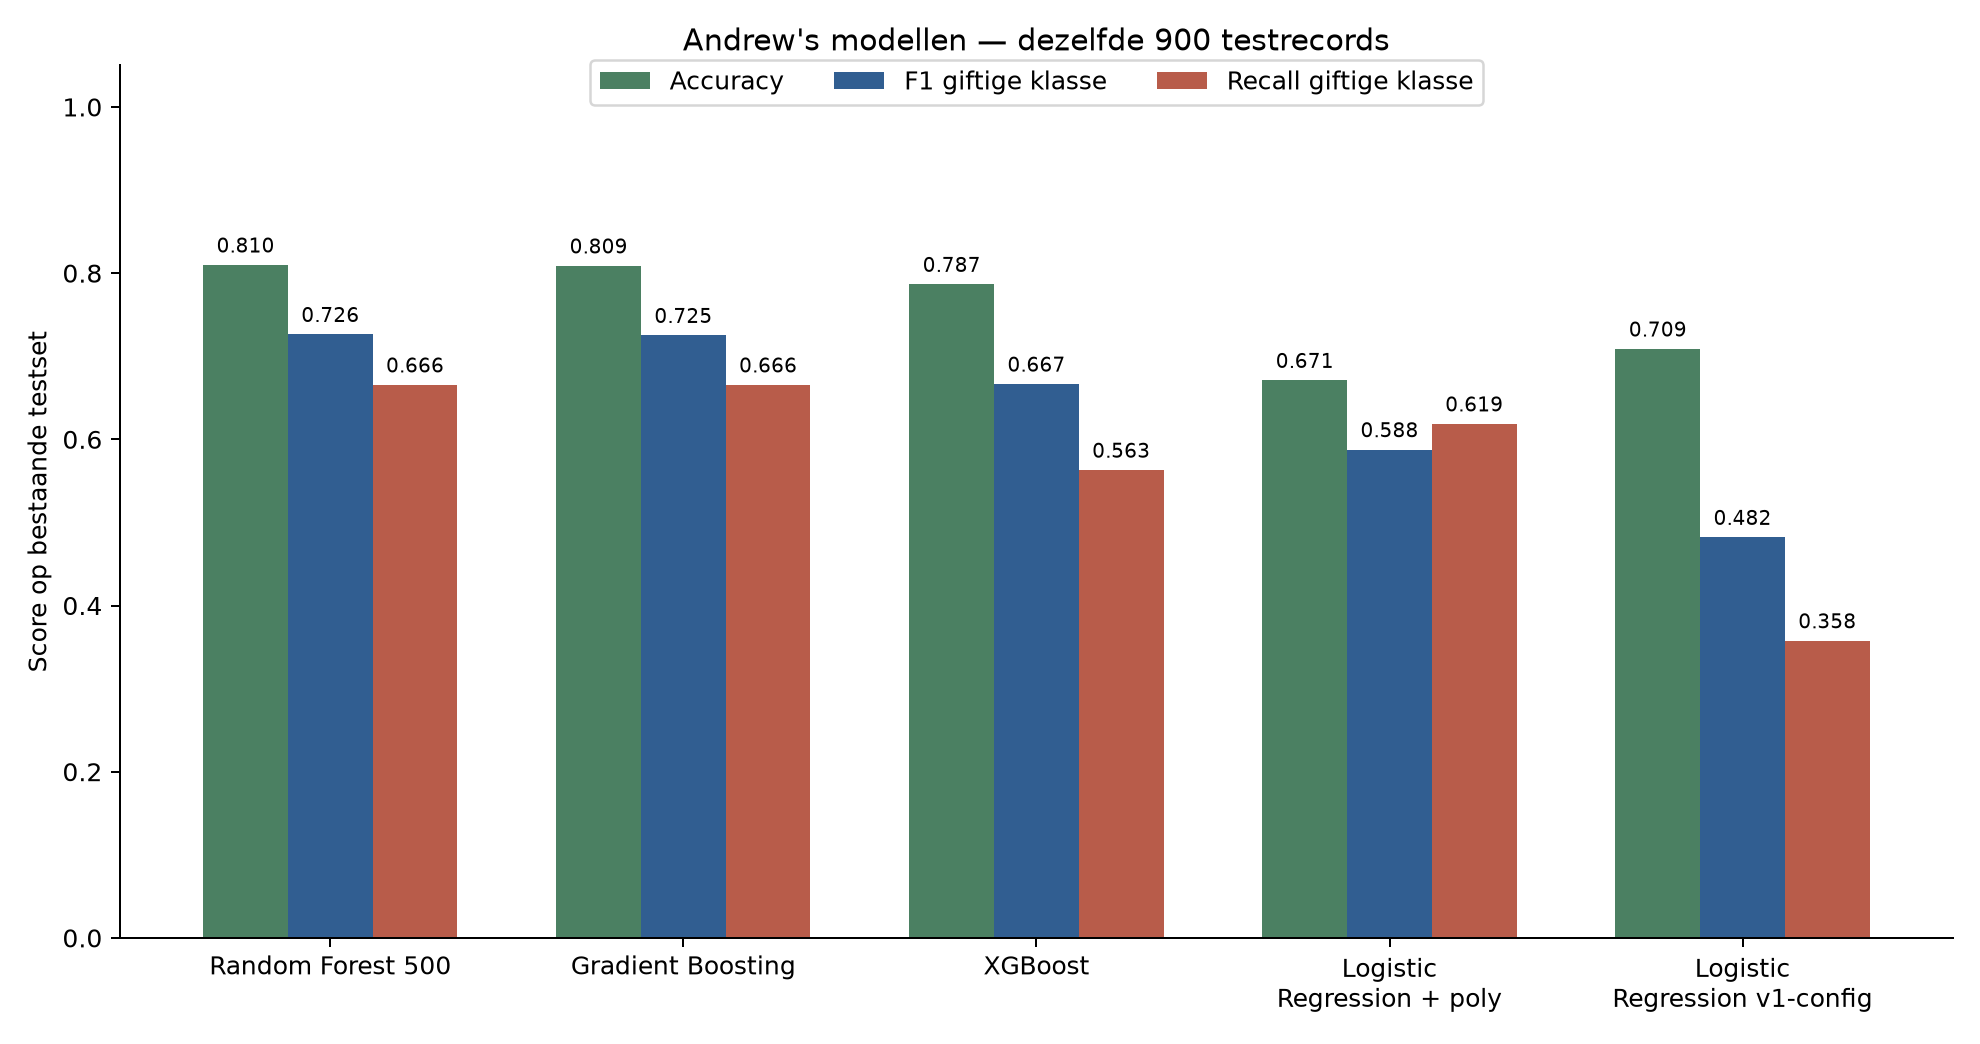

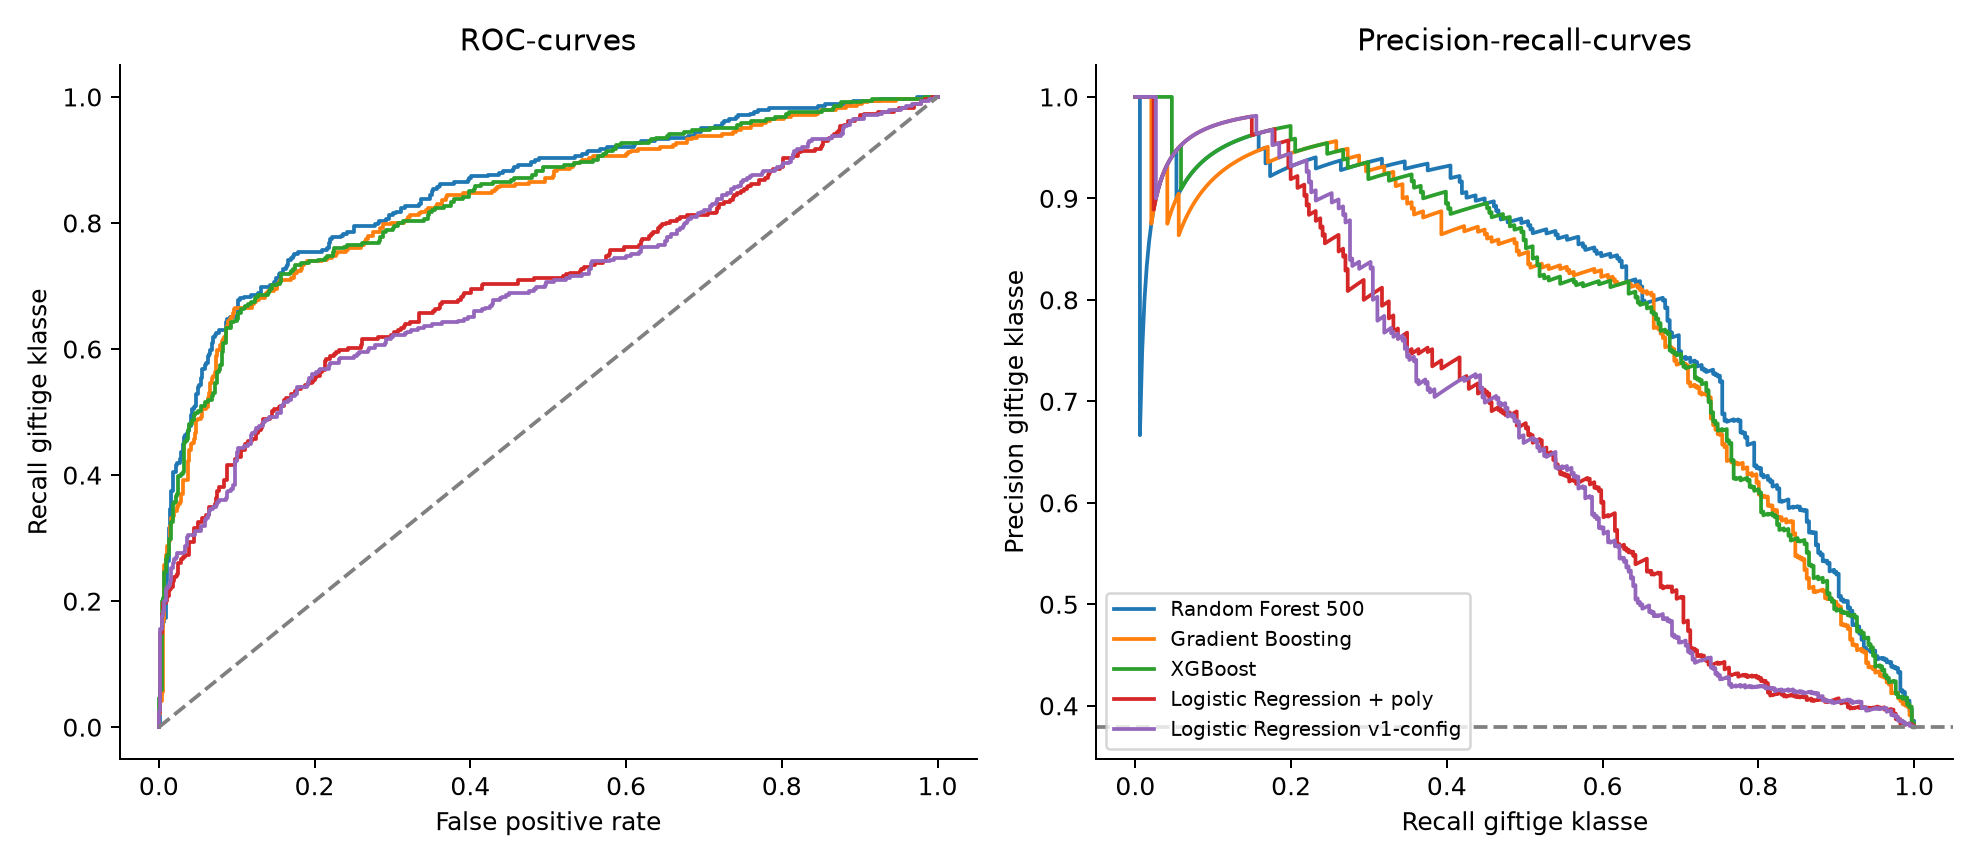

In [5]:
columns = ['accuracy', 'balanced_accuracy', 'precision_poisonous', 'recall_poisonous',
           'f1_poisonous', 'roc_auc', 'average_precision']
display(metrics[columns].round(4))
checks = []
for key, recorded in summary['notebook_recorded_scores'].items():
    row = metrics.loc[key]
    assert round(row.accuracy, 3) == recorded['accuracy_rounded']
    for metric in ['precision_poisonous', 'recall_poisonous', 'f1_poisonous']:
        assert round(row[metric], 2) == recorded[metric + '_rounded']
    checks.append({'model': NAMES[key], 'accuracy bron': recorded['accuracy_rounded'],
                   'accuracy reproductie': row.accuracy, 'overeenkomst afgeronde scores': True})
display(pd.DataFrame(checks))
display(Image(filename=str(OUT / 'metrics_comparison.png')))
display(Image(filename=str(OUT / 'roc_pr_curves.png')))

## 6. Concrete fouten en onzekerheid

Controleer de confusion matrices opnieuw vanuit de individuele voorspellingen. Rijvolgorde
is werkelijk e/p; kolomvolgorde voorspeld e/p. RF500 en Gradient Boosting missen elk 114
van 341 giftige records. Hun accuracy verschilt met één geval. De gepaarde McNemar-toets
is exploratief en test accuracy, niet F1 of veiligheidsbruikbaarheid. p=1,0 bewijst geen
equivalentie; er is geen meervoudige-toetscorrectie toegepast.


,tn,fp,fn,tp
model,,,,
majority,559,0,341,0
random_forest_500,502,57,114,227
gradient_boosting,501,58,114,227
xgboost,516,43,149,192
logistic_polynomial,393,166,130,211
logistic_artifact_config,516,43,219,122


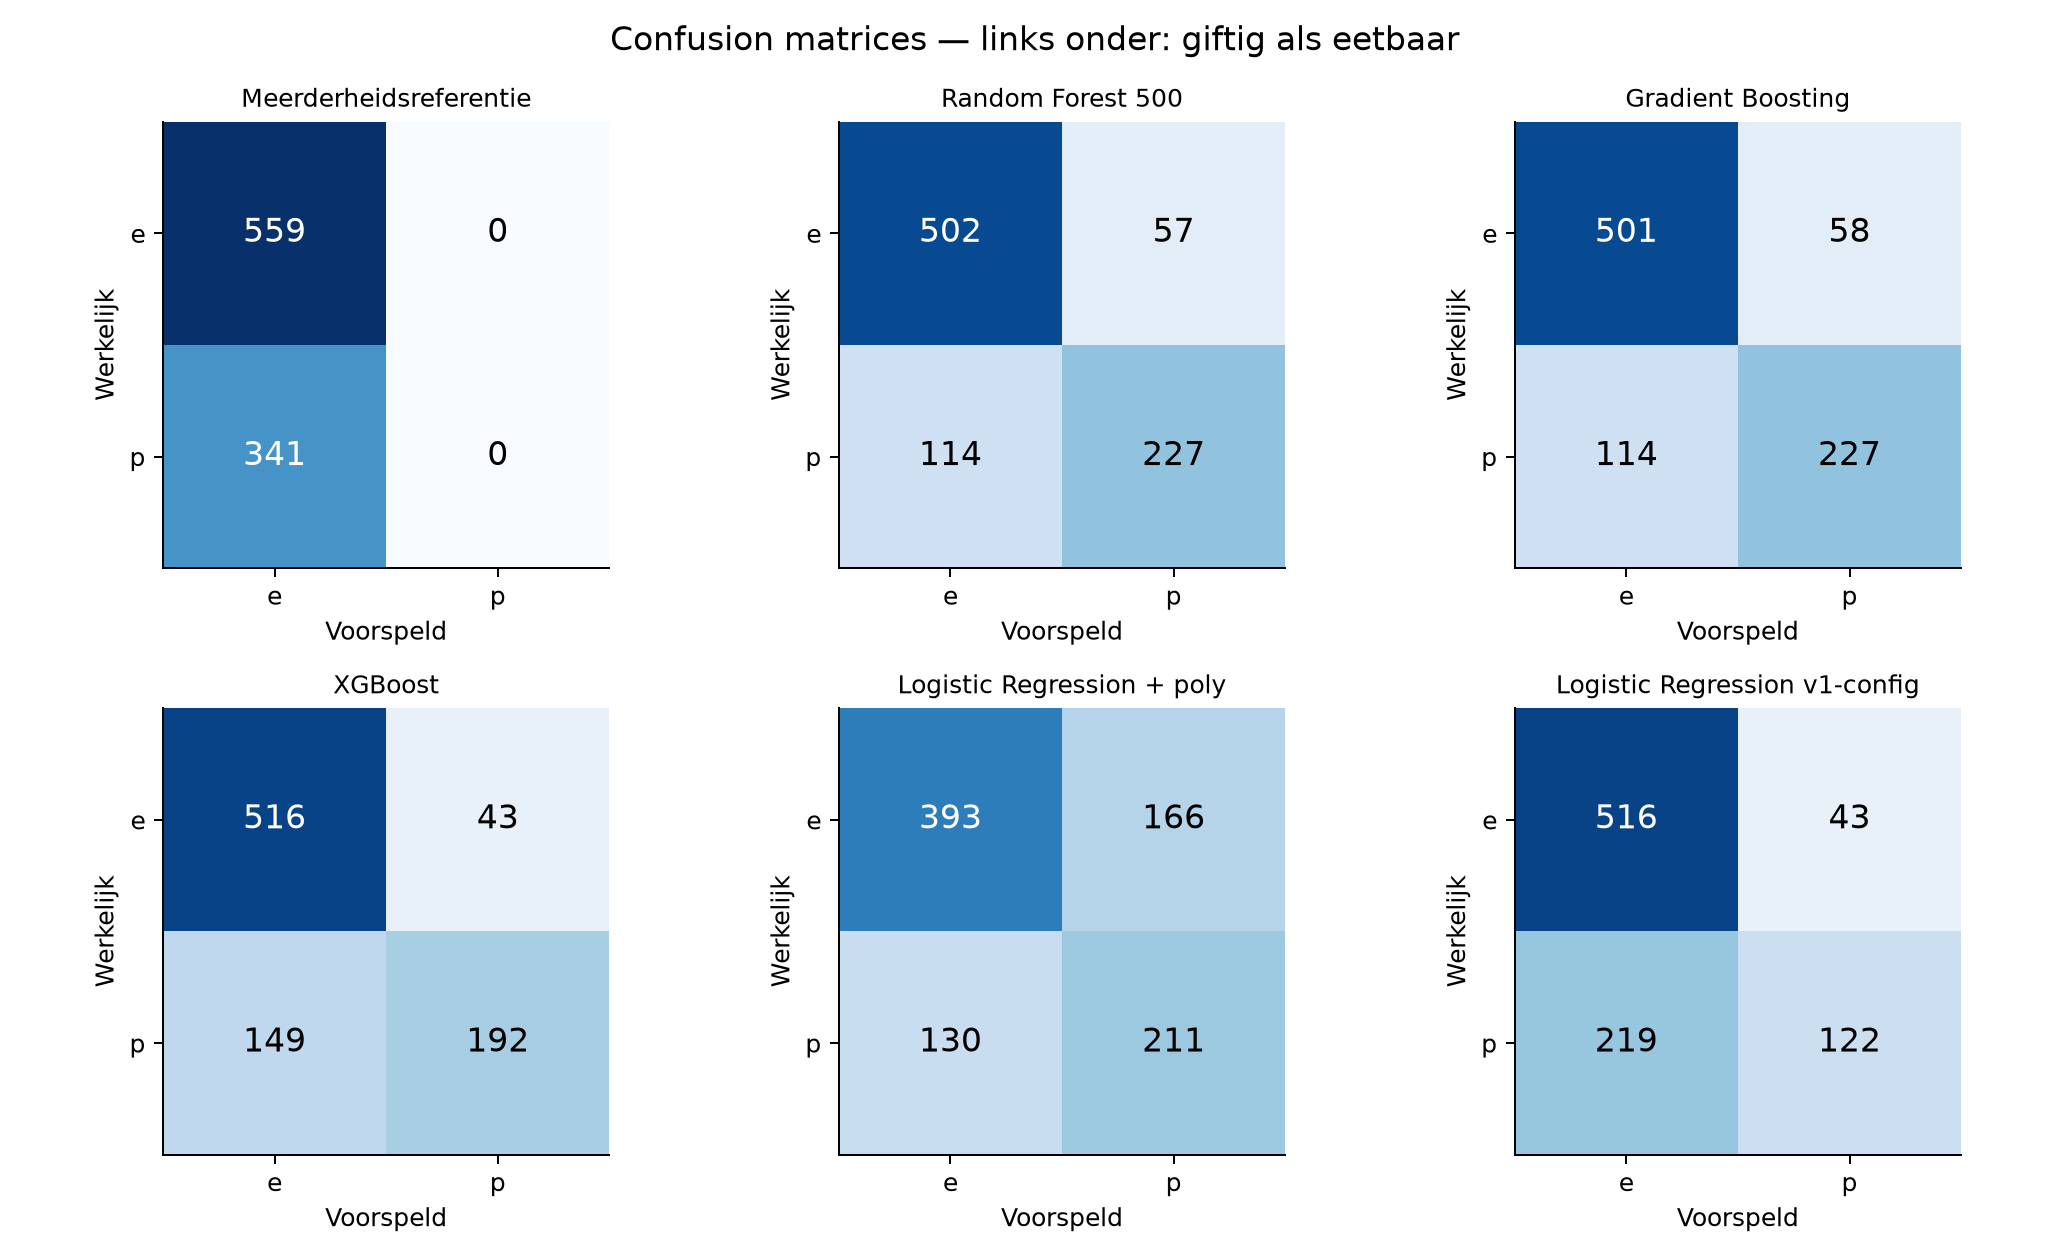

Wilson 95% accuracy: [0.7830732079831068, 0.8342917010442598]
Wilson 95% recall p: [0.6140183836874532, 0.7136684332818374]


,selected,other,only_selected_correct,only_other_correct,accuracy_difference,mcnemar_exact_p
0,random_forest_500,gradient_boosting,40,39,0.001111,1.000000e+00
1,random_forest_500,xgboost,56,35,0.023333,3.544959e-02
2,random_forest_500,logistic_polynomial,178,53,0.138889,5.513180e-17
3,random_forest_500,logistic_artifact_config,135,44,0.101111,5.982174e-12


In [6]:
from sklearn.metrics import confusion_matrix, f1_score, recall_score
y = (predictions.true_class == 'p').astype(int)
for key, row in metrics.iterrows():
    labels = (predictions[key + '_prediction'] == 'p').astype(int)
    cm = confusion_matrix(y, labels, labels=[0, 1])
    assert cm.sum() == 900
    assert cm.ravel().tolist() == [int(row[c]) for c in ['tn', 'fp', 'fn', 'tp']]
    assert abs(f1_score(y, labels, zero_division=0) - row.f1_poisonous) < 1e-12
    assert abs(recall_score(y, labels, zero_division=0) - row.recall_poisonous) < 1e-12
display(metrics[['tn', 'fp', 'fn', 'tp']].astype(int))
display(Image(filename=str(OUT / 'confusion_matrices.png')))
chosen = next(r for r in summary['model_comparison'] if r['model'] == summary['selected_model'])
print('Wilson 95% accuracy:', chosen['accuracy_ci95'])
print('Wilson 95% recall p:', chosen['recall_ci95'])
display(pd.DataFrame(summary['pairwise_accuracy_audit']))

De intervals beschrijven steekproefonzekerheid onder onafhankelijkheid; ze corrigeren
niet voor de reeds bekeken testset of simulatiestructuur. Nu bekijken we de drie giftige
records met de laagste p-score onder de foutieve eetbaar-voorspellingen. De selectie dient
alleen als concrete foutanalyse en leidt niet tot testgestuurde parameterwijzigingen.


In [7]:
assert len(errors) == chosen['fn'] + chosen['fp'] == 171
display(errors[errors.true_class == 'p'].sort_values('probability_p').head(3))
display(pd.DataFrame(summary['selected_false_negative_missingness']))

,source_row,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,true_class,predicted_class,probability_p,missing_features_after_cleaning
0,3875,NaN,NaN,20.71,NaN,f,l,s,f,NaN,NaN,f,x,p,e,0.143512,5
60,1428,NaN,7.32,42.07,NaN,y,d,s,f,o,k,NaN,s,p,e,0.186990,3
39,1106,6.16,6.82,5.51,NaN,n,d,u,l,x,t,x,x,p,e,0.215124,1


,missing_features,poisonous_count,false_negatives,recall
0,1,17,4,0.764706
1,2,72,23,0.680556
2,3,107,30,0.719626
3,4,79,31,0.607595
4,5,55,22,0.600000
5,6,7,1,0.857143
6,7,4,3,0.250000


Rij 3875 mist vijf features; rij 1106 mist er slechts één. Ontbrekendheid is dus geen
afdoende verklaring voor alle FN. De ontbrekendheidsgroepen tonen geen monotone trend en
de hoogste groepen zijn klein. Een oorzaak zoals slechte imputatie is hiermee niet bewezen.

## 7. Featureanalyse op trainingsvalidatie

Permutation importance voor de gekozen RF500 wordt op de eerste CV-validatiefold berekend,
met acht herhalingen en F1 als score. Dit verandert de modelkeuze niet. De foutbalken tonen
spreiding over permutaties, geen onzekerheid over andere datasets. Importance is niet causaal
en gecorreleerde velden kunnen de uitkomst beïnvloeden. Een naam als `jumbled_noise` bewijst
niet dat het veld onafhankelijke ruis is; generatiecode en een vooraf geplande ablation zijn nodig.


,feature,f1_decrease,std
9,stem-surface,0.1219,0.0101
8,cap-shape,0.0900,0.0095
2,stem-width,0.0852,0.0108
4,gill-color,0.0708,0.0163
1,stem-height,0.0495,0.0143
7,ring-type,0.0477,0.0061
6,season,0.0304,0.0053
10,jumbled_noise_0,0.0210,0.0062
0,cap-diameter,0.0160,0.0069
3,spore-print-color,0.0137,0.0038


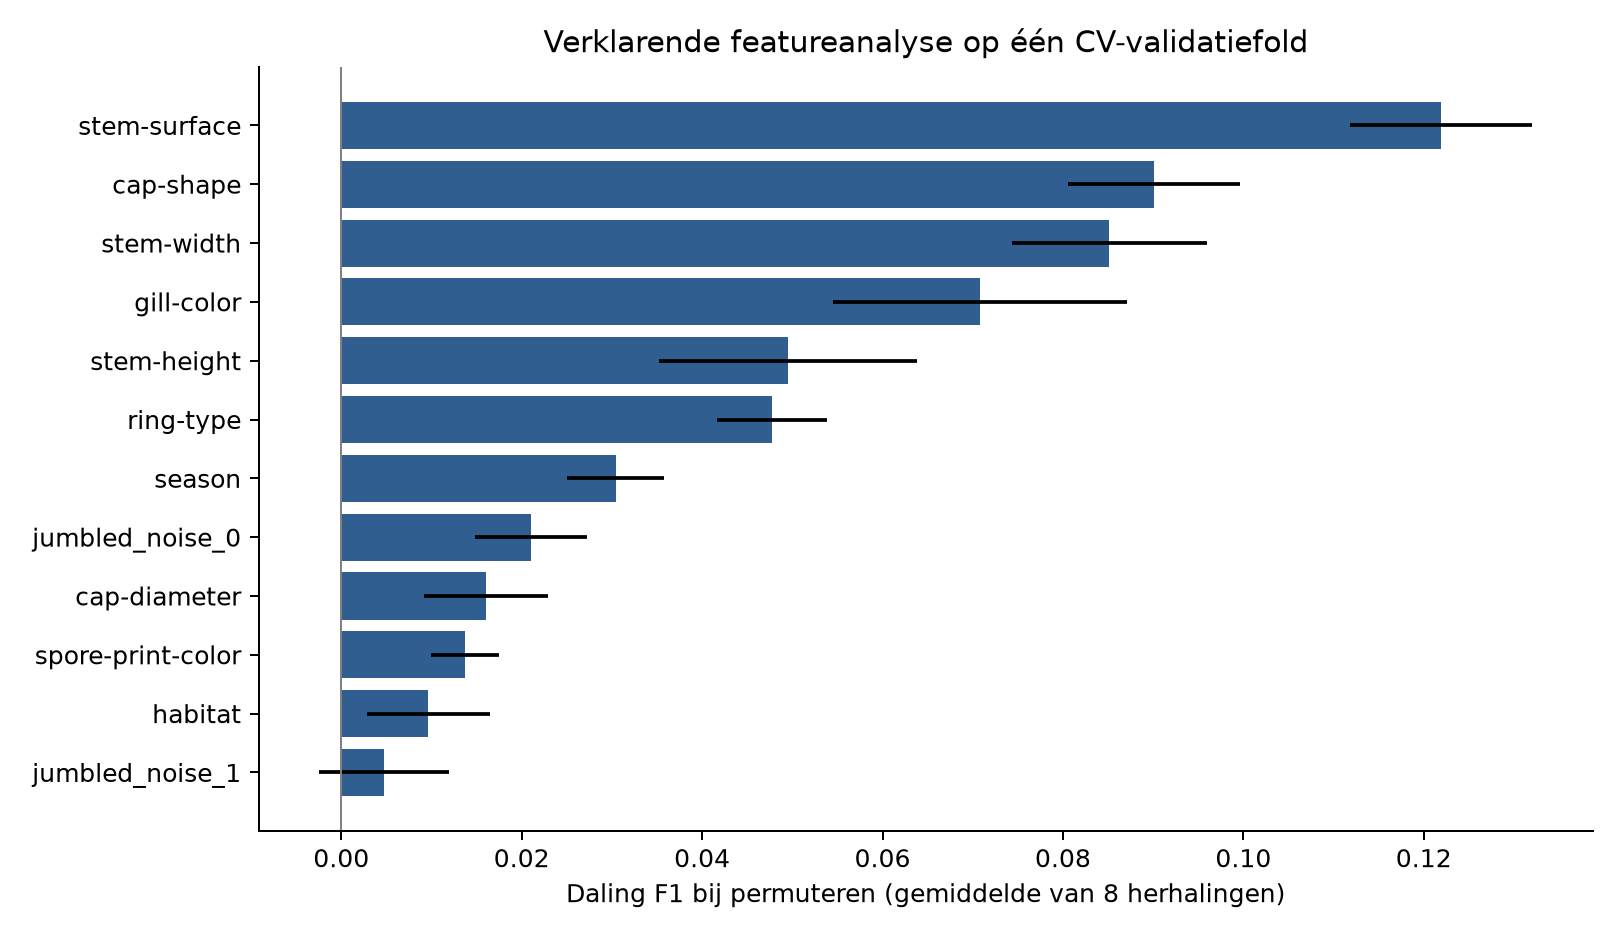

In [8]:
importance = pd.read_csv(OUT / 'permutation_importance.csv').sort_values('f1_decrease', ascending=False)
display(importance.round(4))
display(Image(filename=str(OUT / 'permutation_importance.png')))

## 8. Train-testverschillen en praktische kosten

Vergelijk train- met test-scores als aanwijzing voor overfitting. Gradient Boosting past de
training bijna perfect; het verschil met test is groter dan bij RF500. De LR-varianten
hebben ook beperkte trainingsscores. De timing is lokaal: één fit op 4.100 records en de
mediaan van zeven batches `predict_proba` op 900 records. De pipelinegrootte is voor iedereen
joblib-compressie 3. Dit meet geen Render-responstijd of opstarttijd.


In [9]:
practical = metrics.loc[metrics.index != 'majority',
    ['train_accuracy', 'accuracy', 'train_f1_poisonous', 'f1_poisonous', 'fit_seconds', 'predict_900_ms']].copy()
practical['accuracy train-test verschil'] = practical.train_accuracy - practical.accuracy
practical['pipeline MiB (compressie 3)'] = metrics.serialized_bytes_compress3 / 2**20
display(practical.round(4))
assert all(not counts for counts in summary['warnings'].values())
print('Geen waarschuwingen tijdens de vastgelegde CV- en full-fit runs.')

,train_accuracy,accuracy,train_f1_poisonous,f1_poisonous,fit_seconds,predict_900_ms,accuracy train-test verschil,pipeline MiB (compressie 3)
model,,,,,,,,
random_forest_500,0.9527,0.8100,0.9351,0.7264,1.3638,159.7331,0.1427,8.7071
gradient_boosting,0.9959,0.8089,0.9945,0.7252,7.2654,45.5373,0.1870,1.3666
xgboost,0.8695,0.7867,0.8052,0.6667,1.2295,13.6152,0.0828,0.2598
logistic_polynomial,0.6620,0.6711,0.5693,0.5877,0.0736,9.1283,-0.0092,0.0030
logistic_artifact_config,0.7051,0.7089,0.4737,0.4822,0.0640,9.5846,-0.0038,0.0029


Geen waarschuwingen tijdens de vastgelegde CV- en full-fit runs.


## 9. Onderbouwde conclusie en resterend werk


We kiezen **voorlopig RF500** voor Andrew's huidige probleemdefinitie: de hoogste CV F1 p,
de hoogste CV recall p en bruikbare test-rangschikkingsscores. Gradient Boosting is een
praktisch alternatief bij strengere eisen aan modelgrootte en inference-tijd. Het kleine
accuracyverschil op test is geen geldige hoofdreden voor RF500.

| Resultaat buiten deze vergelijking | Waarom niet in dezelfde ranglijst? |
| --- | --- |
| Andrew's oudere RF200: 78,2% | Andere modelconfiguratie én 80/20-split met 1.000 testrecords; geen zuivere vergelijking met RF500 op 900 records |
| Jorre's AWS RF: 100% | Volledige UCI-versie met 20 features; na deduplicatie 60.923 records en 12.185 testrecords; andere data, preprocessing en validatie |
| Baseline/AutoML op volledige UCI | Pas vergelijkbaar na gedeeld datacontract en evaluatieprotocol |

De AWS-score is dus niet als winnaar aangewezen en ook niet als fout weggezet. Eerst moeten
datasetversie, features, schoonmaak en testrecords overeenkomen. Bij gesimuleerde data moet
het team ook uitleggen welk generalisatiedoel het meet; een random split bewijst geen
prestatie op volledig nieuwe soorten of op echte paddenstoelen.

Voor een definitieve selectie en inlevering blijven deze stappen nodig:

1. Documenteer waar Andrew's CSV vandaan komt en hoe selectie, ontbrekendheid en noise-velden
   zijn gemaakt. Leg één gemeenschappelijke data-/featureversie en split vast voor de
   uiteindelijke teamvergelijking.
2. Voeg baseline, AutoML en alle relevante team-/AWS-modellen toe aan datzelfde protocol.
   Bewaar het tuningtraject, zoekruimte en validatieresultaten; tune niet op de eindtest.
3. Gebruik de foutanalyse voor vooraf gedefinieerde trainingsexperimenten (noise-ablation,
   imputatie/missing indicators, regularisatie, eventueel een recall-doel en kalibratie).
   Rapporteer daarna een onafhankelijke eindbeoordeling en motiveer de echte winnaar.
4. Bewaar één bestand/notebook per model zoals de opdracht vraagt. RF500 en XGBoost moeten
   bij uiteindelijke selectie nog als complete pipeline worden geëxporteerd. Het huidige
   RF200-artifact is daarvoor geen vervanging.
5. Laat de backend de gekozen pipeline met het juiste inputcontract en versies laden en
   controleer API/websitevoorspellingen tegen de notebook. Dit rapport wijzigt de live
   modelkeuze niet; code deployen en een nieuw model trainen/exporteren zijn verschillende stappen.

De analyse gebruikt scikit-learn **1.9.1**; de eerdere RF200-deployment gebruikt **1.8.0**.
Een modelbestand uit een andere versie zomaar laden is geen betrouwbare migratie. Bewaar
versies en valideer de geëxporteerde pipeline in de doelomgeving, zoals beschreven in
[scikit-learn model persistence](https://scikit-learn.org/stable/model_persistence.html).



## 10. Referenties en controleerbare bestanden

- [Volledig rapport en reproduceercommando's](09_andrew_vergelijkingsrapport.md)
- [Reproductiescript](compare_andrew_models.py)
- [Volledige audit en hashes](comparison_andrew/comparison_summary.json)
- [Alle testvoorspellingen](comparison_andrew/test_predictions.csv)
- [UCI Secondary Mushroom](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)
- [scikit-learn cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [scikit-learn permutation importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [scikit-learn model persistence](https://scikit-learn.org/stable/model_persistence.html)
